Sample size per group:
group_label
DII    72
CLR    68
Name: count, dtype: int64


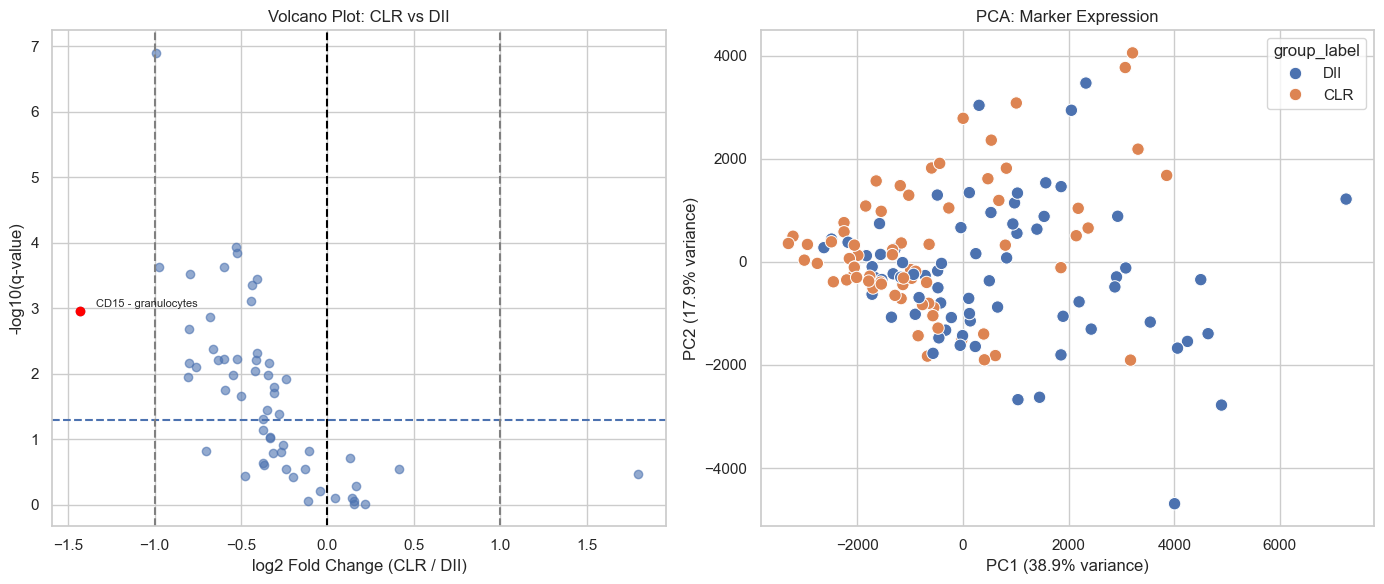

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.patches as patches

sns.set(style="whitegrid")

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")

# Map groups
df["group_label"] = df["groups"].map({1: "CLR", 2: "DII"})

# Remove unwanted cells
df = df[~df['ClusterName'].isin(['dirt', 'undefined'])]
df = df[~df["ClusterName"].str.contains("tumor", case=False, na=False)]

# ==============================
# 2. DEFINE MARKERS
# ==============================
marker_cols = [
    col for col in df.columns
    if ("Cyc_" in col) and ("ch_" in col)
]

marker_name_map = {col: col.split(":")[0] for col in marker_cols}

# ==============================
# 3. (NO PER-SPOT NORMALIZATION)
# ==============================

# ==============================
# 4. AGGREGATE TO SPOT LEVEL
# ==============================
slide_df = (
    df.groupby("spots")[marker_cols]
    .mean()
    .reset_index()
)

groups = df.groupby("spots")["group_label"].first().reset_index()
slide_df = slide_df.merge(groups, on="spots")

# ==============================
# 5. CHECK SAMPLE SIZE
# ==============================
print("Sample size per group:")
print(slide_df["group_label"].value_counts())

# ==============================
# 6. STATISTICAL TESTING
# ==============================
results = []

for marker in marker_cols:

    clr_vals = slide_df[slide_df["group_label"] == "CLR"][marker]
    dii_vals = slide_df[slide_df["group_label"] == "DII"][marker]

    if len(clr_vals) < 3 or len(dii_vals) < 3:
        continue

    stat, p = mannwhitneyu(clr_vals, dii_vals, alternative="two-sided")

    results.append({
        "marker": marker,
        "CLR_mean": clr_vals.mean(),
        "DII_mean": dii_vals.mean(),
        "logFC": np.log2((clr_vals.mean() + 1e-6) / (dii_vals.mean() + 1e-6)),
        "p_value": p
    })

results_df = pd.DataFrame(results)

# ==============================
# 7. FDR CORRECTION
# ==============================
results_df["adj_p_value"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
results_df["neg_log10_q"] = -np.log10(results_df["adj_p_value"] + 1e-10)
results_df["marker_clean"] = results_df["marker"].map(marker_name_map)
# ==============================
# 8 + 9. COMBINED VOLCANO + PCA
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==============================
# VOLCANO
# ==============================
ax = axes[0]

# Define significance
sig = (results_df["adj_p_value"] < 0.05) & (results_df["logFC"].abs() > 1)

# Base points
ax.scatter(results_df["logFC"], results_df["neg_log10_q"], alpha=0.6)

# Significant points
ax.scatter(
    results_df[sig]["logFC"],
    results_df[sig]["neg_log10_q"],
    color="red"
)

# Threshold lines
ax.axhline(-np.log10(0.05), linestyle="--")
ax.axvline(0, color="black", linestyle="--")
ax.axvline(1, linestyle="--", color="grey")   # optional
ax.axvline(-1, linestyle="--", color="grey")  # optional

# Labels
texts = []
top_to_label = results_df[sig].sort_values("adj_p_value").head(10)

for _, row in top_to_label.iterrows():
    texts.append(
        ax.text(
            row["logFC"],
            row["neg_log10_q"],
            row["marker_clean"],
            fontsize=8
        )
    )

adjust_text(texts, ax=ax)

ax.set_xlabel("log2 Fold Change (CLR / DII)")
ax.set_ylabel("-log10(q-value)")
ax.set_title("Volcano Plot: CLR vs DII")

# ==============================
# PCA
# ==============================
ax = axes[1]

X = slide_df[marker_cols].fillna(0)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

slide_df["PC1"] = X_pca[:, 0]
slide_df["PC2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_ * 100

sns.scatterplot(
    data=slide_df,
    x="PC1",
    y="PC2",
    hue="group_label",
    s=80,
    ax=ax
)

ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
ax.set_title("PCA: Marker Expression")

# ==============================
# SAVE FIGURE (600 DPI)
# ==============================
plt.tight_layout()
plt.savefig("Volcano_PCA_Global_Protein_Markers.png", dpi=600)
plt.show()

# ==============================
# SAVE SUPPLEMENTARY TABLE (EXCEL)
# ==============================
results_df_sorted = results_df.sort_values("adj_p_value")

results_df_sorted.to_excel(
    "Supplementary_Table_S4_Global_Protein_Marker.xlsx",
    index=False
)